# Week 2 – Baseline Experiments

In [1]:
!pip install medmnist torch torchvision scikit-learn matplotlib seaborn pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 10.2 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms, models
from medmnist import DermaMNIST, BloodMNIST, INFO
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)
import time
import os

os.makedirs('./figures', exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Using device: cuda


## 1. Configuration

In [3]:
CONFIG = {
    'batch_size': 64,
    'num_epochs': 10,
    'lr': 1e-3,
    'weight_decay': 1e-4,
    'num_workers': 0,
}

## 2. Data Loading

In [4]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def get_loaders(DatasetClass, batch_size, num_workers):
    train_ds = DatasetClass(split='train', transform=transform, download=True)
    val_ds   = DatasetClass(split='val',   transform=transform, download=True)
    test_ds  = DatasetClass(split='test',  transform=transform, download=True)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=num_workers)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=num_workers)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=num_workers)
    return train_loader, val_loader, test_loader

derma_loaders = get_loaders(DermaMNIST, CONFIG['batch_size'], CONFIG['num_workers'])
blood_loaders = get_loaders(BloodMNIST, CONFIG['batch_size'], CONFIG['num_workers'])

n_classes = {
    'dermamnist': len(INFO['dermamnist']['label']),
    'bloodmnist': len(INFO['bloodmnist']['label']),
}
print('Classes — DermaMNIST:', n_classes['dermamnist'], '| BloodMNIST:', n_classes['bloodmnist'])

100%|██████████| 19.7M/19.7M [00:16<00:00, 1.22MB/s]
100%|██████████| 35.5M/35.5M [00:37<00:00, 939kB/s] 


Classes — DermaMNIST: 7 | BloodMNIST: 8


## 3. Model Definition – Linear Probing

In [5]:
def build_linear_probe_model(n_classes):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

    # Freeze EVERY parameter
    for param in model.parameters():
        param.requires_grad = False

    # Replace the final layer
    in_features = model.fc.in_features  # 2048
    model.fc = nn.Linear(in_features, n_classes)

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f'Trainable: {trainable:,} / {total:,} params ({100*trainable/total:.2f}%)')
    return model

## 4. Training and Evaluation Utilities

In [6]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs   = imgs.to(device)
        labels = labels.squeeze().long().to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total = 0.0, 0
    all_preds, all_labels, all_probs = [], [], []
    for imgs, labels in loader:
        imgs   = imgs.to(device)
        labels = labels.squeeze().long().to(device)
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        probs   = torch.softmax(outputs, 1)
        total_loss += loss.item() * imgs.size(0)
        total      += imgs.size(0)
        all_preds.append(outputs.argmax(1).cpu())
        all_labels.append(labels.cpu())
        all_probs.append(probs.cpu())

    all_preds  = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    all_probs  = torch.cat(all_probs).numpy()

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    try:
        auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
    except ValueError:
        auc = float('nan')

    return {'loss': total_loss/total, 'accuracy': acc, 'f1_macro': f1,
            'auc_roc': auc, 'preds': all_preds, 'labels': all_labels}

## 5. Full Training Loop

In [7]:
def run_experiment(dataset_name, loaders, n_cls, config, device):
    print(f"\n{'='*60}\n  Linear Probing Baseline — {dataset_name.upper()}\n{'='*60}")
    train_loader, val_loader, test_loader = loaders

    model     = build_linear_probe_model(n_cls).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=config['lr'], weight_decay=config['weight_decay']
    )
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_auc': []}
    best_val_acc = 0.0
    os.makedirs('./models', exist_ok=True)
    start = time.time()

    for epoch in range(1, config['num_epochs'] + 1):
        t_loss, t_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        v = evaluate(model, val_loader, criterion, device)
        scheduler.step()

        history['train_loss'].append(t_loss)
        history['train_acc'].append(t_acc)
        history['val_loss'].append(v['loss'])
        history['val_acc'].append(v['accuracy'])
        history['val_auc'].append(v['auc_roc'])

        if v['accuracy'] > best_val_acc:
            best_val_acc = v['accuracy']
            torch.save(model.state_dict(), f'./models/best_{dataset_name}_linear_probe.pth')

        print(f"Epoch {epoch:02d}/{config['num_epochs']} | "
              f"Train Loss: {t_loss:.4f} Acc: {t_acc:.4f} | "
              f"Val Loss: {v['loss']:.4f} Acc: {v['accuracy']:.4f} AUC: {v['auc_roc']:.4f}")

    training_time = time.time() - start
    model.load_state_dict(torch.load(f'./models/best_{dataset_name}_linear_probe.pth',
                                     map_location=device))
    test_m = evaluate(model, test_loader, criterion, device)
    test_m['training_time_s'] = training_time

    print(f"\n--- Test Results ({dataset_name}) ---")
    print(f"  Top-1 Accuracy: {test_m['accuracy']:.4f}")
    print(f"  Macro F1:       {test_m['f1_macro']:.4f}")
    print(f"  AUC-ROC (OvR):  {test_m['auc_roc']:.4f}")
    print(f"  Training time:  {training_time:.1f}s")
    return history, test_m


derma_history, derma_test = run_experiment(
    'dermamnist', derma_loaders, n_classes['dermamnist'], CONFIG, DEVICE)

blood_history, blood_test = run_experiment(
    'bloodmnist', blood_loaders, n_classes['bloodmnist'], CONFIG, DEVICE)


  Linear Probing Baseline — DERMAMNIST
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 204MB/s]


Trainable: 14,343 / 23,522,375 params (0.06%)
Epoch 01/10 | Train Loss: 0.9362 Acc: 0.6907 | Val Loss: 0.7582 Acc: 0.7388 AUC: 0.8970
Epoch 02/10 | Train Loss: 0.7735 Acc: 0.7200 | Val Loss: 0.7247 Acc: 0.7448 AUC: 0.9076
Epoch 03/10 | Train Loss: 0.7458 Acc: 0.7323 | Val Loss: 0.7259 Acc: 0.7438 AUC: 0.9086
Epoch 04/10 | Train Loss: 0.7288 Acc: 0.7328 | Val Loss: 0.7214 Acc: 0.7348 AUC: 0.9131
Epoch 05/10 | Train Loss: 0.6875 Acc: 0.7465 | Val Loss: 0.7015 Acc: 0.7408 AUC: 0.9154
Epoch 06/10 | Train Loss: 0.6648 Acc: 0.7555 | Val Loss: 0.7097 Acc: 0.7468 AUC: 0.9172
Epoch 07/10 | Train Loss: 0.6579 Acc: 0.7612 | Val Loss: 0.6857 Acc: 0.7517 AUC: 0.9170
Epoch 08/10 | Train Loss: 0.6654 Acc: 0.7537 | Val Loss: 0.7070 Acc: 0.7308 AUC: 0.9145
Epoch 09/10 | Train Loss: 0.6437 Acc: 0.7620 | Val Loss: 0.6801 Acc: 0.7517 AUC: 0.9187
Epoch 10/10 | Train Loss: 0.6439 Acc: 0.7585 | Val Loss: 0.7066 Acc: 0.7308 AUC: 0.9142

--- Test Results (dermamnist) ---
  Top-1 Accuracy: 0.7471
  Macro F1:   

## 6. Learning Curves

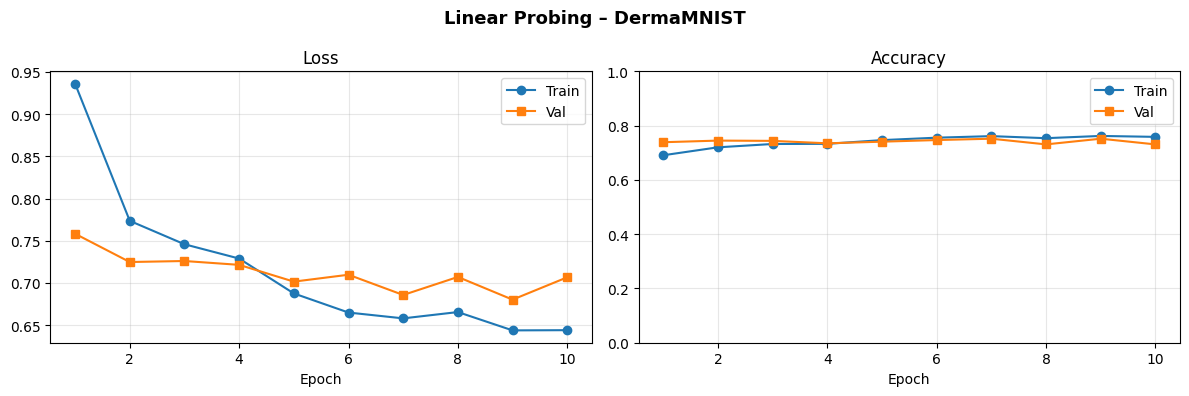

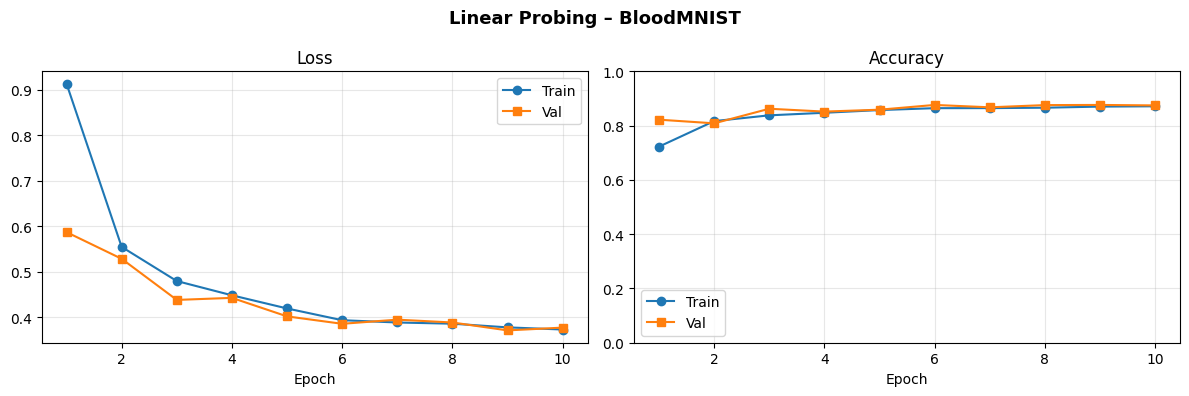

In [10]:
def plot_learning_curves(history, dataset_name):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'Linear Probing – {dataset_name}', fontsize=13, fontweight='bold')

    axes[0].plot(epochs, history['train_loss'], label='Train', marker='o')
    axes[0].plot(epochs, history['val_loss'],   label='Val',   marker='s')
    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, history['train_acc'], label='Train', marker='o')
    axes[1].plot(epochs, history['val_acc'],   label='Val',   marker='s')
    axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch')
    axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'./figures/{dataset_name}_linear_probe_curves.png', dpi=100)
    plt.show()

plot_learning_curves(derma_history, 'DermaMNIST')
plot_learning_curves(blood_history, 'BloodMNIST')

## 7. Confusion Matrices

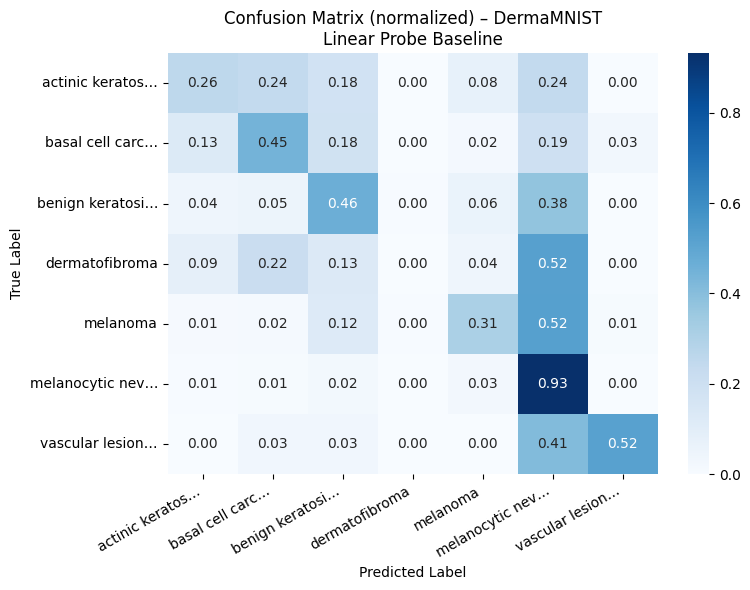

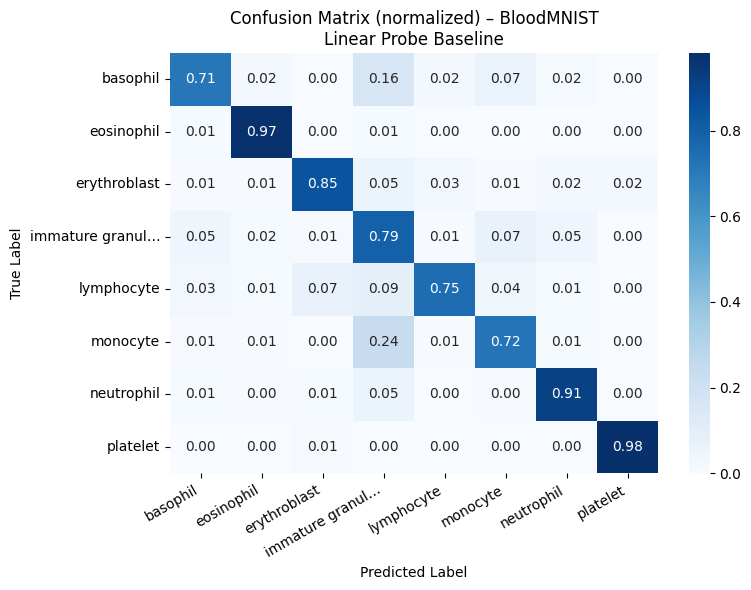

In [17]:
def plot_confusion_matrix(metrics, dataset_info_key, dataset_name):
    label_names = list(INFO[dataset_info_key]['label'].values())
    label_names = [l[:15] + '…' if len(l) > 15 else l for l in label_names]
    cm = confusion_matrix(metrics['labels'], metrics['preds'])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names, ax=ax)
    ax.set_title(f'Confusion Matrix (normalized) – {dataset_name}\nLinear Probe Baseline')
    ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig(f'./figures/{dataset_info_key}_confusion_matrix.png', dpi=100)
    plt.show()

plot_confusion_matrix(derma_test, 'dermamnist', 'DermaMNIST')
plot_confusion_matrix(blood_test, 'bloodmnist', 'BloodMNIST')

## 8. Classification Report

In [13]:
for name, key, m in [('DermaMNIST', 'dermamnist', derma_test), ('BloodMNIST', 'bloodmnist', blood_test)]:
    label_names = list(INFO[key]['label'].values())
    print(f'\n=== {name} – Classification Report ===')
    print(classification_report(m['labels'], m['preds'], target_names=label_names, zero_division=0))


=== DermaMNIST – Classification Report ===
                                                 precision    recall  f1-score   support

actinic keratoses and intraepithelial carcinoma       0.32      0.26      0.29        66
                           basal cell carcinoma       0.48      0.45      0.46       103
                  benign keratosis-like lesions       0.53      0.46      0.49       220
                                 dermatofibroma       0.00      0.00      0.00        23
                                       melanoma       0.54      0.31      0.39       223
                               melanocytic nevi       0.83      0.93      0.88      1341
                               vascular lesions       0.62      0.52      0.57        29

                                       accuracy                           0.75      2005
                                      macro avg       0.48      0.42      0.44      2005
                                   weighted avg       0.72      

## 9. Summary Table

In [16]:
import pandas as pd

results = pd.DataFrame([
    {'Method': 'Linear Probing (ResNet-50 frozen)', 'Dataset': 'DermaMNIST',
     'Top-1 Acc': f"{derma_test['accuracy']:.4f}", 'Macro F1': f"{derma_test['f1_macro']:.4f}",
     'AUC-ROC': f"{derma_test['auc_roc']:.4f}", 'Train Time (s)': f"{derma_test['training_time_s']:.1f}"},
    {'Method': 'Linear Probing (ResNet-50 frozen)', 'Dataset': 'BloodMNIST',
     'Top-1 Acc': f"{blood_test['accuracy']:.4f}", 'Macro F1': f"{blood_test['f1_macro']:.4f}",
     'AUC-ROC': f"{blood_test['auc_roc']:.4f}", 'Train Time (s)': f"{blood_test['training_time_s']:.1f}"},
])

print(results.to_string(index=False))
results.to_csv('./figures/W2_baseline_results.csv', index=False)

                           Method    Dataset Top-1 Acc Macro F1 AUC-ROC Train Time (s)
Linear Probing (ResNet-50 frozen) DermaMNIST    0.7471   0.4400  0.9019          411.5
Linear Probing (ResNet-50 frozen) BloodMNIST    0.8652   0.8436  0.9816          739.4
